In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [220]:
import pandas as pd
temp_df = pd.read_csv('../data/AAPL_data.csv', nrows=0)
print(temp_df.columns.tolist())


['Price', 'Close', 'High', 'Low', 'Open', 'Volume']


In [221]:
df = pd.read_csv("../data/AAPL_data.csv", index_col="Price", parse_dates=True)
print(df.shape)
print(df.head())

(2518, 5)
                         Close                High                 Low  \
Price                                                                    
Ticker                    AAPL                AAPL                AAPL   
Date                       NaN                 NaN                 NaN   
2015-01-02   24.19260025024414  24.659502293956603  23.754464067072234   
2015-01-05  23.511062622070312  24.042136374239757  23.325187737341313   
2015-01-06  23.513269424438477    23.7721672375332   23.15258108261458   

                          Open     Volume  
Price                                      
Ticker                    AAPL       AAPL  
Date                       NaN        NaN  
2015-01-02  24.648437592390618  212818400  
2015-01-05  23.962475227002493  257142000  
2015-01-06  23.575227702283048  263188400  


C:\Users\Welcome\AppData\Local\Temp\ipykernel_17512\3526746204.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("../data/AAPL_data.csv", index_col="Price", parse_dates=True)


In [222]:
print(df.iloc[2].apply(type))   #numerical numbers are read as strings

Close     <class 'str'>
High      <class 'str'>
Low       <class 'str'>
Open      <class 'str'>
Volume    <class 'str'>
Name: 2015-01-02, dtype: object


In [223]:
# Convert all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

adding a new column as "return" and pct_change() calculates how much the price moved in percentage terms each day. If the stock went from $100 to $102, the return is 0.02 (2%). This is the core signal everything else is built from.

In [224]:
df["return"] = df["Close"].pct_change()

In [225]:
print(df.head())

                Close       High        Low       Open       Volume    return
Price                                                                        
Ticker            NaN        NaN        NaN        NaN          NaN       NaN
Date              NaN        NaN        NaN        NaN          NaN       NaN
2015-01-02  24.192600  24.659502  23.754464  24.648438  212818400.0       NaN
2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000.0 -0.028171
2015-01-06  23.513269  23.772167  23.152581  23.575228  263188400.0  0.000094


Financial markets often display short-term patterns that lag variables expose: <br>
**Momentum:** If lag1 and lag2 are highly positive, the asset might be in a strong upward trend.<br>
**Mean Reversion:** If an asset went up too high over lag1, lag2, and lag3, it might be due for a downward correction.<br><br>
shift(1) moves the column down by one row — so today's row now contains yesterday's value. You're giving the model a short memory of recent price movements.

In [226]:
df["lag1"] = df["return"].shift(1)  # yesterday's return
df["lag2"] = df["return"].shift(2)  # two days ago
df["lag3"] = df["return"].shift(3)  # three days ago

In [227]:
df["sma5"]  = df["Close"].rolling(5).mean() # Average of the last 5 days
df["sma20"] = df["Close"].rolling(20).mean() # Average of the last 20 days
df["sma50"] = df["Close"].rolling(50).mean() # Average of the last 50 days

#### Price relative to moving average
| Result | What it means |
|---|---|
| **= 1.0** | Stock is trading *exactly* at its average — perfectly normal |
| **> 1.0** (e.g. 1.15) | Stock is trading *above* its average — it's been running hot |
| **< 1.0** (e.g. 0.85) | Stock is trading *below* its average — it's been cooling off |

This code is comparing today's stock price to the moving averages you calculated before. It's asking:

In [228]:
df["price_to_sma20"] = df["Close"] / df["sma20"]
df["price_to_sma50"] = df["Close"] / df["sma50"]
df["sma_cross"] = df["sma5"] / df["sma20"] 

In [229]:
# Momentum
df["momentum_5"]  = df["Close"] / df["Close"].shift(5)  - 1
df["momentum_20"] = df["Close"] / df["Close"].shift(20) - 1

Standard deviation of returns over the last 10 or 20 days. High volatility means the stock has been jumping around a lot lately. Low volatility means it's been calm. The model can use this to adjust its confidence.

In [230]:
df["volatility_10"] = df["return"].rolling(10).std()
df["volatility_20"] = df["return"].rolling(20).std()
df["vol_ratio"]     = df["volatility_10"] / df["volatility_20"]

RSI(Relative Strength Index) runs from 0 to 100. Above 70 generally means the stock has been rising fast and might be due for a pullback. Below 30 means the opposite. It's one of the most commonly used momentum indicators.

In [231]:
def compute_rsi(series, period=14):
    delta = series.diff()                                   #Calculates the day-to-day price change in dollars (not %)
    gain  = delta.clip(lower=0).rolling(period).mean()       #Calculates the average gain over the specified period
    loss  = -delta.clip(upper=0).rolling(period).mean()      #Calculates the average loss over the specified period
    rs    = gain / loss                                      #The ratio of average gain to average loss
    return 100 - (100 / (1 + rs))                            #A formula that squashes RS into the 0–100 range

df["rsi"] = compute_rsi(df["Close"])
df["rsi_slope"] = df["rsi"] - df["rsi"].shift(3)

In [232]:
# df["volume_change"] = df["Volume"].pct_change()
df["volume_ma20"]   = df["Volume"].rolling(20).mean()
df["volume_ratio"]  = df["Volume"] / df["volume_ma20"]
df["vol_confirmed_move"] = df["lag1"] * df["volume_ratio"]

# volume ratio 2.0 --> 2x the normal volume (something big is happening)
# volume ratio 0.5 --> half the normal volume (quiet day)

In [233]:
df.index = pd.to_datetime(df.index, errors="coerce")
df = df[df.index.notna()]
df["day_of_week"] = df.index.dayofweek


C:\Users\Welcome\AppData\Local\Temp\ipykernel_17512\3211531019.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


In [234]:
df["target"] = (df["return"].shift(-1) > 0).astype(int)

# shift(-1) moves the column up by one row — so today's row gets tomorrow's return value
# > 0 turns it into True/False — did it go up?
# .astype(int) converts True → 1, False → 0

In [235]:
df.dropna(inplace=True)
print(f"Dataset shape after dropping NaNs: {df.shape}")
print(df.head())

Dataset shape after dropping NaNs: (2467, 27)
                Close       High        Low       Open       Volume    return  \
Price                                                                           
2015-03-16  27.758121  27.758121  27.296043  27.520417  143497200.0  0.011004   
2015-03-17  28.222429  28.284632  27.913636  27.969174  204092400.0  0.016727   
2015-03-18  28.540108  28.693394  28.073585  28.213541  261083600.0  0.011256   
2015-03-19  28.324615  28.713385  28.302400  28.602308  183238000.0 -0.007551   
2015-03-20  27.969170  28.524553  27.804776  28.491231  274780400.0 -0.012549   

                lag1      lag2      lag3       sma5  ...  volatility_10  \
Price                                                ...                  
2015-03-16 -0.006911  0.018079 -0.018232  27.535528  ...       0.012886   
2015-03-17  0.011004 -0.006911  0.018079  27.647937  ...       0.014304   
2015-03-18  0.016727  0.011004 -0.006911  27.924741  ...       0.014748   
2015-03-19 

Lags → What has the stock been doing recently? <br>
SMA / price ratio → Is it trending up or down overall? <br>
RSI → Has it moved too far too fast? <br>
Volatility → How risky is the current environment? <br>
Volume → Is there real conviction behind recent moves? <br>

In [236]:
print("Features created:")
print(df.columns.tolist())
print(f"\nDate range: {df.index[0]} to {df.index[-1]}")
print(f"Total rows: {len(df)}")

Features created:
['Close', 'High', 'Low', 'Open', 'Volume', 'return', 'lag1', 'lag2', 'lag3', 'sma5', 'sma20', 'sma50', 'price_to_sma20', 'price_to_sma50', 'sma_cross', 'momentum_5', 'momentum_20', 'volatility_10', 'volatility_20', 'vol_ratio', 'rsi', 'rsi_slope', 'volume_ma20', 'volume_ratio', 'vol_confirmed_move', 'day_of_week', 'target']

Date range: 2015-03-16 00:00:00 to 2024-12-31 00:00:00
Total rows: 2467


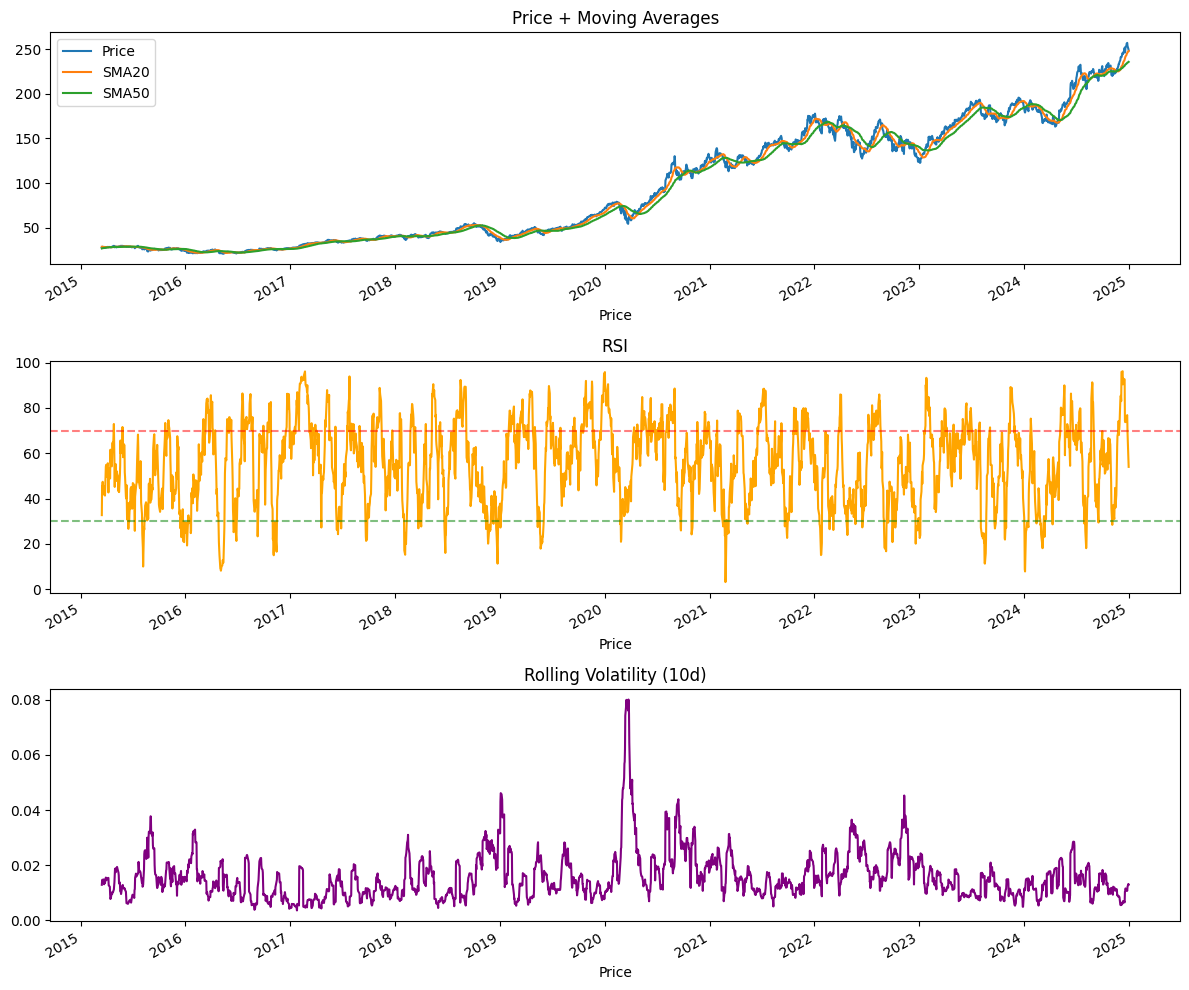

In [237]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

df["Close"].plot(ax=axes[0], title="Price + Moving Averages")
df["sma20"].plot(ax=axes[0])
df["sma50"].plot(ax=axes[0])
axes[0].legend(["Price", "SMA20", "SMA50"])

df["rsi"].plot(ax=axes[1], title="RSI", color="orange")
axes[1].axhline(70, color="red",   linestyle="--", alpha=0.5)
axes[1].axhline(30, color="green", linestyle="--", alpha=0.5)

df["volatility_10"].plot(ax=axes[2], title="Rolling Volatility (10d)", color="purple")

plt.tight_layout()
plt.show()

In [238]:
df.to_csv("../data/AAPL_features.csv")
print("Saved to ../data/AAPL_features.csv")

Saved to ../data/AAPL_features.csv
